In [51]:
import pandas as pd
import numpy as np
import sklearn
import os
import matplotlib as plt
import seaborn as sns

**pclass**: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...
**Sibling** = brother, sister, stepbrother, stepsister
**Spouse** = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

In [3]:
datapath = '/home/sidyaniv/Desktop/projects/kaggle_competitions/titanic/dataset/titanic'
gender_submission_name = 'gender_submission.csv'
test_name = 'test.csv'
train_name = 'train.csv'

target_data = pd.read_csv(os.path.join(datapath, gender_submission_name), index_col='PassengerId')
test_data = pd.read_csv(os.path.join(datapath, test_name), index_col='PassengerId')
train_data  = pd.read_csv(os.path.join(datapath, train_name), index_col='PassengerId')

In [ ]:
useless_names = ['Name', 'Ticket', 'Cabin']     # Удаляем Cabin так как она почти пустая. Остальное - не нужно

train_data.drop(columns=useless_names, inplace=True)
test_data.drop(columns=useless_names, inplace=True)

In [ ]:
# Rename columns
rename = {'SibSp': 'br_sister_partner', 'Parch': 'parents_childs', 
          'Fare': 'ticket_cost', 'Embarked': 'port_name'}
train_data.rename(columns=rename, inplace=True)
test_data.rename(columns=rename, inplace=True)

In [ ]:
# 1)Sex можно закодировать через one-hot encoding, тк. всего 2 класса
# 2)Pclass можно как-то закодировать через количество/долю выживших этого класса
# 3)Cabin можно как-то закодировать через количество/долю выживших этого класса
# 4)port_name можно как-то закодировать через количество/долю выживших этого класса
# 5)Удалю все объекты с пропусками для baseline

train_cleared = train_data.dropna(subset=['Age', 'port_name', 'ticket_cost'])
test_cleared = test_data.dropna(subset=['Age', 'port_name', 'ticket_cost'])

# train_cleared.info()
# train_data.info()

1) Сначала загоним данные без нормировки, самым деревянным способом (через легкие кодировки)

/tmp/ipykernel_32066/2137659391.py:4: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.catplot(data=train_cleared, x='Pclass', hue='Sex', kind='count', palette = custom_colors)


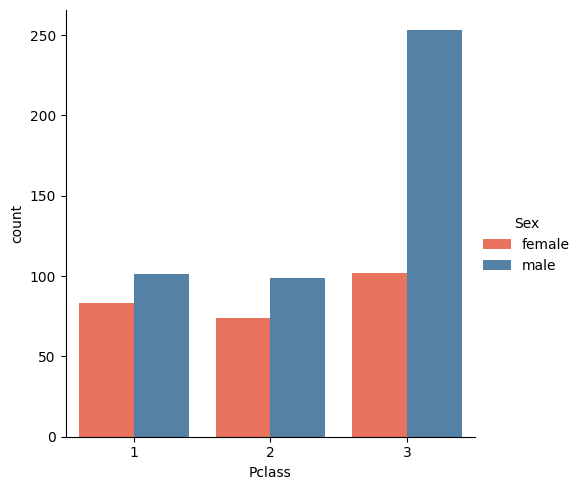

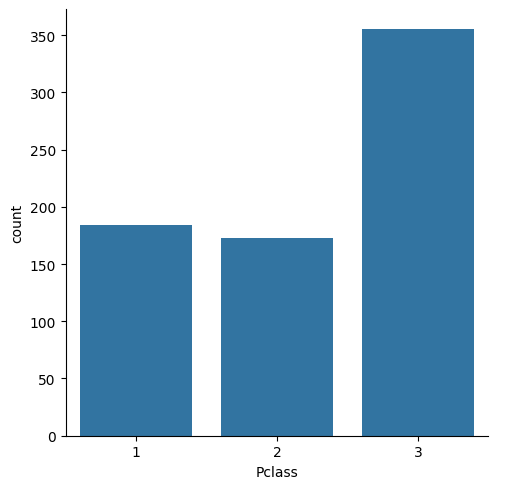

In [70]:
# Visualization
custom_colors = ['#FF6347', '#4682B4', '#32CD32']
# sns.catplot(data=train_cleared, x='Sex', hue='Pclass', kind='count', palette = custom_colors)
sns.catplot(data=train_cleared, x='Pclass', hue='Sex', kind='count', palette = custom_colors)
sns.catplot(data=train_cleared, x = 'Pclass', kind='count')

In [ ]:
train_cleared

In [ ]:
# enoding
train_clerad_encoded = pd.get_dummies(train_cleared, columns = [])